# Transformer로 번역기 만들기 (한국어 → 영어) — 개선본

> **Attention Is All You Need** 논문의 Transformer를 직접 구현하여 한-영 번역기를 완성하는 프로젝트입니다.
> 이 노트북은 **새 Google Colab 환경에서 위에서부터 순서대로 실행**하면 그대로 동작하도록 정리된 버전입니다.

## 프로젝트 목적
- Transformer의 핵심 구성요소(Positional Encoding, Multi-Head Attention, Feed-Forward, Masking)를 직접 구현합니다.
- Encoder–Decoder 구조를 조립해 Sequence-to-Sequence 번역 모델을 완성합니다.
- SentencePiece 토큰화, Warmup 학습률 스케줄, 마스킹된 손실 등 **실제 학습 파이프라인**을 경험합니다.
- 학습된 모델로 예문을 번역하고 **BLEU 점수와 Attention Map**으로 평가합니다.

## 목차
**0. 환경 설정** — 라이브러리 설치 · GPU 확인  
**1. 데이터 다운로드** — 한-영 병렬 말뭉치 확보  
**2. 데이터 정제 및 토큰화**  
&nbsp;&nbsp;2-1. 중복 제거  
&nbsp;&nbsp;2-2. 정제 함수  
&nbsp;&nbsp;2-3. SentencePiece 토큰화  
&nbsp;&nbsp;2-4. 길이 필터링  
&nbsp;&nbsp;train/valid 분리  
**3. 모델 설계** — Transformer 구성요소 구현  
**4. 훈련하기**  
&nbsp;&nbsp;4-1. 모델 선언  
&nbsp;&nbsp;4-2. Optimizer & LR Scheduler  
&nbsp;&nbsp;4-3. Loss  
&nbsp;&nbsp;4-4. Train Step  
&nbsp;&nbsp;4-5. 번역/시각화 함수
&nbsp;&nbsp;4-6. 학습 실행  
&nbsp;&nbsp;BLEU 평가

## 주의사항
- **런타임 유형을 GPU로 설정**하세요: 상단 메뉴 `런타임 > 런타임 유형 변경 > 하드웨어 가속기 = GPU (T4)`. CPU로는 학습이 매우 느립니다.
- 셀은 **반드시 위에서부터 순서대로** 실행하세요. 뒤 셀이 앞 셀에서 정의한 변수를 사용합니다.
- 전체 데이터를 쓰면 학습이 오래 걸리므로 **토큰 길이 50 이하** 문장만 사용합니다.
- `EPOCHS`, `BATCH_SIZE`, `vocab_size` 등 하이퍼파라미터는 자유롭게 조절할 수 있습니다.
- Colab 세션이 끊기면 `/content` 의 데이터·모델이 사라집니다. 필요하면 결과를 Google Drive에 저장하세요.
- 이 노트북은 원본 프로젝트의 **실행 차단 버그**와 **학습이 안 되던 문제**를 수정한 버전입니다. 수정 지점은 코드에 `# ` 주석으로 표시했습니다.
  - 실행 차단: 마스킹 규약 반전, optimizer 정의 순서, 손실 함수 차원, positional encoding 타입, import 누락, GPU 이동
  - 학습 품질: **Xavier 가중치 초기화**(loss 폭주 방지 — 원본은 초기 loss가 수천대로 치솟음), **교차 어텐션 마스크 교정**(디코더가 소스 전체 참조), **그래디언트 클리핑**
-  **추가 개선**(`#  개선` 주석): train/valid 분리 + **best 에폭 가중치 저장/복원**, **반복 억제 디코딩**(no-repeat 3-gram), **label smoothing(0.1)**, **BLEU 정량 평가**, Attention 시각화 폰트(`▁`) 정리

## 평가 루브릭
| 번호 | 평가 문항 | 상세 기준 |
|:---:|---|---|
| 1 | 번역기 모델 학습에 필요한 전처리가 적절히 이루어졌는가? | 중복 제거·정제·SentencePiece 토큰화·패딩이 정상 수행되어 `enc_train`, `dec_train` 텐서가 만들어짐 |
| 2 | Transformer 번역기 모델이 정상적으로 구현되었는가? | Multi-Head Attention·Encoder/Decoder·Masking·Positional Encoding이 올바르게 구현되어 학습 loss가 감소함 |
| 3 | 번역 결과와 Attention이 시각화되어 정성적으로 평가되었는가? | 예문 번역·BLEU 점수·Attention Map 시각화가 제시됨 |

> 제출 시 **하이퍼파라미터**와 **예문 번역 결과(및 BLEU)**를 함께 기록하세요.

## 0. 환경 설정
---
필요한 라이브러리를 설치하고 연산 장치(GPU/CPU)를 설정합니다.

In [3]:
# SentencePiece 설치 + BLEU 평가용 sacrebleu (Colab 기본 이미지에 없을 수 있어 명시적으로 설치)
!pip install -q sentencepiece sacrebleu
# (선택) Attention 시각화 시 한글 라벨이 깨지지 않도록 나눔폰트 설치
!apt-get -qq install -y fonts-nanum > /dev/null

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.9 MB/s eta 0:00:00


In [4]:
# ===== 기본 라이브러리 =====
import os, re, random            # re: 정제(정규식), random: 배치 셔플 ( 원본에서 누락되어 추가)
import math, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from tqdm.auto import tqdm       # Colab/터미널 모두 호환되는 진행바

# ===== 재현성을 위한 시드 고정 =====
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ===== 한글 폰트 등록 (있을 때만) =====
_font = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(_font):
    fm.fontManager.addfont(_font)
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ===== 연산 장치 설정 (GPU 우선) =====
#  원본에는 device 이동이 없어 CPU로만 동작 -> Colab GPU 활용을 위해 추가
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__, '| 사용 장치:', device)

PyTorch: 2.11.0+cu128 | 사용 장치: cuda


## 1. 데이터 다운로드
---
한-영 병렬 말뭉치 [`jungyeul/korean-parallel-corpora`](https://github.com/jungyeul/korean-parallel-corpora) 를 내려받습니다.
(약 94,000개의 한국어–영어 문장 쌍)

In [5]:
# 데이터 폴더 생성 (-p: 이미 있어도 에러 없음 → 재실행 안전)
!mkdir -p /content/data

# 압축 파일 다운로드 후 tar.gz 를 한 번에 해제 (-C: 대상 폴더 지정)
!wget -q -O /content/data/corpus.tar.gz https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
!tar -xzf /content/data/corpus.tar.gz -C /content/data

# ko / en 파일이 생성되었는지 확인
!ls -lh /content/data/korean-english-park.train.*

-rw-r--r-- 1 501 staff 12M Jul 12  2014 /content/data/korean-english-park.train.en
-rw-r--r-- 1 501 staff 14M Jul 12  2014 /content/data/korean-english-park.train.ko


## 2. 데이터 정제 및 토큰화
---
### 2-1. 중복 제거
`set` 이 중복을 허용하지 않는 성질을 이용해 문장 쌍을 통째로 중복 제거합니다.
한글과 영어를 **탭(\t)으로 묶어** 처리하므로 병렬 쌍의 정렬이 흐트러지지 않습니다.

In [6]:
data_dir = '/content/data'
kor_path = data_dir + "/korean-english-park.train.ko"
eng_path = data_dir + "/korean-english-park.train.en"

def clean_corpus(kor_path, eng_path):
    with open(kor_path, "r") as f: kor = f.read().splitlines()
    with open(eng_path, "r") as f: eng = f.read().splitlines()
    assert len(kor) == len(eng)                      # 병렬 쌍 개수 일치 확인

    # "한글\t영어" 로 묶어 set 에 넣으면 쌍 단위로 중복이 제거됨
    cleaned_corpus = list(set(["\t".join([k, e]) for k, e in zip(kor, eng)]))
    return cleaned_corpus

cleaned_corpus = clean_corpus(kor_path, eng_path)
print("중복 제거 후 문장 쌍 수:", len(cleaned_corpus))

중복 제거 후 문장 쌍 수: 78968


### 2-2. 정제 함수
- 모든 입력을 소문자로 변환 · 알파벳/한글/일부 문장부호만 남기기
- 문장부호 양옆에 공백 추가 · 앞뒤 불필요한 공백 제거

In [7]:
def preprocess_sentence(sentence):
    sentence = sentence.lower()                          # 소문자 통일
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)  # 알파벳/한글/문장부호만 남김
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)    # 문장부호 양옆 공백
    sentence = re.sub(r'[" "]+', " ", sentence)           # 연속 공백을 하나로
    return sentence.strip()                              # 앞뒤 공백 제거

# 동작 확인
print(preprocess_sentence("Hello,   World!  안녕하세요."))

hello , world ! 안녕하세요 .


### 2-3. SentencePiece 토큰화
[`google/sentencepiece`](https://github.com/google/sentencepiece) 로 서브워드 토크나이저를 학습합니다.
특수 토큰 인덱스는 `<PAD>=0`, `<BOS>=1`, `<EOS>=2`, `<UNK>=3` 으로 지정합니다.
타겟(영어) 토크나이저는 문장 시작/끝에 `<BOS>`, `<EOS>` 를 자동으로 붙입니다.

In [8]:
import sentencepiece as spm

def generate_tokenizer(corpus, vocab_size, lang="ko",
                       pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    file  = "./%s_corpus.txt" % lang      # 학습용 임시 텍스트 파일
    model = "%s_spm" % lang               # 모델 파일 prefix

    # 말뭉치를 한 줄씩 파일로 저장 (SentencePiece 학습 입력)
    with open(file, 'w') as f:
        for row in corpus:
            f.write(str(row) + '\n')

    #  원본 버그 수정:
    #   (1) '--vocab_size=%d' 뒤 공백 누락으로 다음 인자와 붙어버림
    #   (2) '--pad_id==%d' 등호(=)가 2개인 오타
    #   -> f-string 으로 인자 사이 공백을 확실히 넣어 재작성
    spm.SentencePieceTrainer.Train(
        f'--input={file} --model_prefix={model} --vocab_size={vocab_size} '
        f'--pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}'
    )

    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load('%s.model' % model)    # 학습된 모델 로드 후 반환
    return tokenizer


SRC_VOCAB_SIZE = TGT_VOCAB_SIZE = 20000

# cleaned_corpus 를 한글/영어로 분리하며 각각 정제
kor_corpus, eng_corpus = [], []
for pair in cleaned_corpus:
    k, e = pair.split("\t")
    kor_corpus.append(preprocess_sentence(k))
    eng_corpus.append(preprocess_sentence(e))

ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")   # 소스(한국어)
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")   # 타겟(영어)
en_tokenizer.set_encode_extra_options("bos:eos")   # 타겟 문장에 <BOS>...<EOS> 자동 부착
print("토크나이저 생성 완료 | ko vocab:", ko_tokenizer.get_piece_size(),
      "| en vocab:", en_tokenizer.get_piece_size())

토크나이저 생성 완료 | ko vocab: 20000 | en vocab: 20000


### 2-4. 길이 필터링 · train/valid 분리
토큰 길이가 **50 이하**인 문장 쌍만 선별해 텐서로 만들고, **학습셋/검증셋으로 분리**합니다.
(검증셋은 과적합 모니터링과 best 모델 선택에 사용합니다.)

In [9]:
src_corpus, tgt_corpus = [], []
assert len(kor_corpus) == len(eng_corpus)

# 토큰 길이가 50 이하인 문장만 남김
for idx in tqdm(range(len(kor_corpus)), desc="토큰화/길이필터"):
    src_tokens = ko_tokenizer.encode_as_ids(kor_corpus[idx])
    tgt_tokens = en_tokenizer.encode_as_ids(eng_corpus[idx])   # <BOS>...<EOS> 포함
    if len(src_tokens) <= 50 and len(tgt_tokens) <= 50:
        src_corpus.append(torch.tensor(src_tokens, dtype=torch.long))
        tgt_corpus.append(torch.tensor(tgt_tokens, dtype=torch.long))

def pad_sequences(sequences, padding_value=0):
    # 배치 내 문장 길이를 <PAD>(0)로 맞춤. batch_first -> (문장수, 최대길이)
    return torch.nn.utils.rnn.pad_sequence(
        sequences, batch_first=True, padding_value=padding_value)

enc_all = pad_sequences(src_corpus, padding_value=0)     # 인코더 입력 (한국어)
dec_all = pad_sequences(tgt_corpus, padding_value=0)     # 디코더 입력 (영어)

#  개선: train/valid 분리 (검증 손실 모니터링 + best 모델 선택에 사용)
n_total = enc_all.shape[0]
n_val = min(3000, n_total // 20)                          # 검증셋 크기 (최대 3000문장)
perm = torch.randperm(n_total, generator=torch.Generator().manual_seed(42))
val_idx, tr_idx = perm[:n_val], perm[n_val:]
enc_train, dec_train = enc_all[tr_idx], dec_all[tr_idx]
enc_val,   dec_val   = enc_all[val_idx], dec_all[val_idx]
print("train:", enc_train.shape, "| valid:", enc_val.shape)

토큰화/길이필터:   0%|          | 0/78968 [00:00<?, ?it/s]

train: torch.Size([69107, 50]) | valid: torch.Size([3000, 50])


## 3. 모델 설계
---
Transformer를 구성하는 모듈을 순서대로 구현합니다.
### Positional Encoding
순서 정보가 없는 Attention에 위치 정보를 더해 줍니다. (짝수 차원=sin, 홀수 차원=cos)

In [10]:
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, int(i) / d_model)
    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(p) for p in range(pos)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])   # 짝수 차원: sin
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])   # 홀수 차원: cos
    return sinusoid_table   # numpy 배열 (Transformer 내부에서 텐서로 변환해 사용)

### Multi-Head Attention
입력을 여러 Head로 나눠 Scaled Dot-Product Attention을 병렬 수행한 뒤 다시 합칩니다.

In [11]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads          # Head 당 차원
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.W_q = nn.Linear(d_model, d_model)     # Query 투영
        self.W_k = nn.Linear(d_model, d_model)     # Key 투영
        self.W_v = nn.Linear(d_model, d_model)     # Value 투영
        self.linear = nn.Linear(d_model, d_model)  # 출력 투영

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = K.shape[-1]
        QK = torch.matmul(Q, K.transpose(-2, -1))              # 유사도 점수
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        if mask is not None:
            #  원본 버그 수정: masked_fill(mask == 0, ...) -> (mask != 0, ...)
            #   이 코드의 마스크 규약은 "1 = 차단, 0 = 허용" 이다.
            #   따라서 값이 0이 아닌(=차단해야 할) 위치를 -inf 로 채워야 한다.
            #   원본은 반대로 실제 토큰을 가려버려 학습이 되지 않는다.
            scaled_qk = scaled_qk.masked_fill(mask != 0, float('-1e9'))

        attentions = F.softmax(scaled_qk, dim=-1)              # 어텐션 가중치
        out = torch.matmul(attentions, V)
        return out, attentions

    def split_heads(self, x):
        bsz, seq_len, _ = x.shape
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)               # (batch, heads, seq, depth)

    def combine_heads(self, x):
        bsz, _, seq_len, _ = x.shape
        x = x.permute(0, 2, 1, 3).contiguous()
        return x.view(bsz, seq_len, self.d_model)  # 다시 (batch, seq, d_model)

    def forward(self, Q, K, V, mask=None):
        WQ = self.split_heads(self.W_q(Q))
        WK = self.split_heads(self.W_k(K))
        WV = self.split_heads(self.W_v(V))

        out, attention_weights = self.scaled_dot_product_attention(WQ, WK, WV, mask)
        out = self.combine_heads(out)
        return self.linear(out), attention_weights

### Position-wise Feed-Forward Network
각 위치에 동일하게 적용되는 2층 완전연결망입니다. (`d_model` → `d_ff` → `d_model`)

In [12]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)    # 확장
        self.fc2 = nn.Linear(d_ff, d_model)    # 복원
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

### Encoder / Decoder Layer
Pre-LayerNorm 구조로 각 서브층(Attention/FFN) 앞에 정규화를 두고 잔차 연결(residual)을 더합니다.

In [13]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        # (1) Multi-Head Self-Attention + 잔차 연결
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.dropout(out) + residual

        # (2) Feed-Forward + 잔차 연결
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.dropout(out) + residual
        return out, enc_attn

In [14]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)   # 디코더 Self-Attention
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)    # 인코더-디코더 Attention
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, causality_mask, padding_mask):
        # (1) Masked Self-Attention: 미래 토큰/PAD 를 가림 (padding_mask 사용)
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, padding_mask)
        out = self.dropout(out) + residual

        # (2) Encoder-Decoder Attention: 디코더가 인코더 출력을 참조 (causality_mask 사용)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, causality_mask)
        out = self.dropout(out) + residual

        # (3) Feed-Forward
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out) + residual
        return out, dec_attn, dec_enc_attn

In [15]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.n_layers = n_layers
        # EncoderLayer 를 n_layers 만큼 쌓음
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

    def forward(self, x, mask):
        enc_attns = []
        out = x
        for layer in self.enc_layers:
            out, enc_attn = layer(out, mask)
            enc_attns.append(enc_attn)     # 시각화를 위해 각 층의 어텐션 저장
        return out, enc_attns

In [16]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

    def forward(self, x, enc_out, causality_mask, padding_mask):
        dec_attns, dec_enc_attns = [], []
        out = x
        for layer in self.dec_layers:
            out, dec_attn, dec_enc_attn = layer(out, enc_out, causality_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns

### Transformer 완성
임베딩 + Positional Encoding → Encoder → Decoder → 출력층(Linear) 으로 조립합니다.

In [17]:
class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared=True):
        super().__init__()
        self.d_model = d_model
        self.shared = shared

        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        #  원본 버그 수정: positional_encoding() 은 numpy 배열이라 .unsqueeze() 가 불가능.
        #   torch 텐서로 변환한 뒤 register_buffer 로 등록하면
        #   model.to(device) 시 파라미터처럼 같은 장치로 자동 이동한다.
        pe = torch.tensor(positional_encoding(pos_len, d_model), dtype=torch.float32)
        self.register_buffer('pos_encoding', pe)

        self.dropout = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.fc = nn.Linear(d_model, tgt_vocab_size)

        if shared:                          # 출력층 가중치를 디코더 임베딩과 공유
            self.fc.weight = self.dec_emb.weight

        self._reset_parameters()            #  추가: 가중치 초기화 (아래 설명)

    def _reset_parameters(self):
        #  원본 문제 수정 (loss 폭주 원인):
        #   PyTorch 기본 nn.Embedding 초기화는 N(0,1) 이라 분산이 크다.
        #   여기에 embedding() 의 d_model 스케일링과 출력층 가중치 공유가 겹치면
        #   로짓(logit)이 폭주해 초기 loss 가 수천대로 치솟고 번역이 깨진다.
        #   -> 2차원 이상 파라미터를 Xavier 로 초기화해 로짓 크기를 정상 범위로 맞춘다.
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def embedding(self, emb, x):
        seq_len = x.shape[1]
        out = emb(x)
        if self.shared:                     # 임베딩 스케일링 (d_model)
            out = out * torch.sqrt(torch.tensor(self.d_model, dtype=torch.float32, device=x.device))
        # 위치 정보 더하기 (buffer 라 이미 x 와 같은 장치에 있음)
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        return self.dropout(out)

    def forward(self, enc_in, dec_in, enc_mask, causality_mask, dec_mask):
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)

        enc_out, enc_attns = self.encoder(enc_in, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in, enc_out, causality_mask, dec_mask)

        logits = self.fc(dec_out)           # (batch, tgt_len, tgt_vocab_size)
        return logits, enc_attns, dec_attns, dec_enc_attns

### Masking
- **Padding Mask**: `<PAD>`(0) 위치를 가려 어텐션이 패딩을 참조하지 않게 합니다.
- **Look-ahead(Causality) Mask**: 디코더 self-attention이 미래 토큰을 미리 보지 못하게 합니다.
- **Cross-Attention Mask**: 디코더는 소스 문장 전체를 참조해야 하므로 인코더 **패딩 마스크만** 사용합니다.
- 마스크 규약: **값 1 = 차단, 0 = 허용**

In [18]:
def generate_padding_mask(seq):
    # <PAD>(0) 위치를 1로 표시 (1=차단). shape: (batch, 1, 1, seq_len)
    mask = (seq == 0).float()
    return mask[:, None, None, :]

def generate_causality_mask(src_len, tgt_len):
    # 대각선 위쪽(미래 위치)을 1로 표시해 참조를 차단
    mask = 1 - torch.cumsum(torch.eye(src_len, tgt_len), dim=0)
    return mask.float()

def generate_masks(src, tgt):
    enc_mask = generate_padding_mask(src)      # 인코더 self-attn: 소스 PAD 차단
    dec_pad_mask = generate_padding_mask(tgt)

    # 디코더 self-attn: PAD 이거나 미래 토큰이면 차단 (둘 중 하나라도 1이면 1)
    look_ahead_mask = generate_causality_mask(tgt.shape[1], tgt.shape[1]).to(dec_pad_mask.device)
    dec_mask = torch.max(dec_pad_mask, look_ahead_mask)

    # 인코더-디코더(cross) attention 마스크
    #  원본 수정: 원본은 여기에 causal 마스크를 씌워 디코더가 소스의 '앞부분'만 보게 했다.
    #   번역은 어순이 달라 소스 전체를 참조해야 하므로, 교차 어텐션에는
    #   '인코더 패딩 마스크'만 사용해 디코더가 모든 소스 토큰을 볼 수 있게 한다.
    dec_enc_mask = enc_mask
    return enc_mask, dec_enc_mask, dec_mask

## 4. 훈련하기
---
### 4-1. 모델 선언
2-Layer Transformer를 선언합니다. 하이퍼파라미터는 자유롭게 조절하세요.

In [19]:
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,
    dropout=0.2,
    shared=True
).to(device)     #  원본 누락분: 모델을 GPU/CPU 로 이동

n_params = sum(p.numel() for p in transformer.parameters()) / 1e6
print(f"모델 파라미터 수: {n_params:.1f}M | 장치: {next(transformer.parameters()).device}")

모델 파라미터 수: 35.2M | 장치: cuda:0


### 4-2. Optimizer & Learning Rate Scheduler
논문 4.3절의 Warmup 스케줄과 동일한 파라미터의 Adam Optimizer를 사용합니다.
$$lr = d_{model}^{-0.5} \cdot \min(step^{-0.5},\ step \cdot warmup^{-1.5})$$

In [20]:
# PyTorch 버전에 따라 기반 클래스 이름이 다를 수 있어 안전하게 선택
_BaseScheduler = getattr(torch.optim.lr_scheduler, "LRScheduler",
                         torch.optim.lr_scheduler._LRScheduler)

class LearningRateScheduler(_BaseScheduler):
    def __init__(self, optimizer, d_model, warmup_steps=4000, last_epoch=-1):
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        step = max(1, self.last_epoch)
        arg1 = step ** -0.5                       # 이후: 서서히 감소
        arg2 = step * (self.warmup_steps ** -1.5) # warmup 구간: 선형 증가
        lr = (self.d_model ** -0.5) * min(arg1, arg2)
        return [lr for _ in self.base_lrs]

In [21]:
#  원본 버그 수정: 정의 순서를 바로잡음.
#   원본은 optimizer 를 만들기 전에 scheduler(optimizer, ...) 를 호출하고
#   optimizer.param_groups 를 참조해 NameError 가 발생했다.
#   -> 반드시 optimizer 를 먼저 생성한 뒤 scheduler 를 만든다.
optimizer = torch.optim.Adam(
    transformer.parameters(),
    lr=0.0,                       # 실제 lr 은 매 step 스케줄러가 갱신
    betas=(0.9, 0.98), eps=1e-9   # 논문과 동일한 하이퍼파라미터
)
scheduler = LearningRateScheduler(optimizer, d_model=512, warmup_steps=4000)
print("Optimizer & Scheduler 준비 완료")

Optimizer & Scheduler 준비 완료


### 4-3. Loss 함수
Sequence-to-sequence 손실에 **마스킹**을 적용하고, `<PAD>` 를 제외한 실제 토큰 수로 정규화합니다.

In [22]:
#  개선: label_smoothing=0.1 -- 정답에 100% 확신하지 않게 해 과신·반복을 완화 (논문 설정)
loss_object = torch.nn.CrossEntropyLoss(reduction='none', label_smoothing=0.1)

def loss_function(real, pred):
    # real: (batch, seq) 정답 토큰 인덱스 / pred: (batch, seq, vocab) 로짓
    mask = (real != 0).float()                 # <PAD>(0) 위치는 손실 계산에서 제외

    #  원본 버그 수정: CrossEntropyLoss 는 (batch, vocab, seq) 형태를 요구.
    #   pred 는 (batch, seq, vocab) 이므로 transpose(1,2) 로 클래스 차원을 앞으로 옮긴다.
    loss_ = loss_object(pred.transpose(1, 2), real)

    loss_ = loss_ * mask
    return loss_.sum() / mask.sum()            # 실제 토큰 개수로 스케일링

### 4-4. Train Step
입력에 알맞은 마스크를 생성해 모델에 전달하고, 역전파로 파라미터를 갱신합니다.

In [23]:
def train_step(src, tgt, model, optimizer):
    src, tgt = src.to(device), tgt.to(device)   #  입력을 모델과 같은 장치로 이동
    gold = tgt[:, 1:]                           # 정답: <BOS> 다음 토큰부터

    # 입력 데이터에 맞는 마스크 생성
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt)

    optimizer.zero_grad()
    predictions, enc_attns, dec_attns, dec_enc_attns = \
        model(src, tgt, enc_mask, dec_enc_mask, dec_mask)

    # 예측의 마지막 위치를 제외해 gold 와 길이를 맞춤 (teacher forcing)
    loss = loss_function(gold, predictions[:, :-1])

    loss.backward()      # 역전파
    #  추가: 그래디언트 클리핑 -- warmup 초반 학습 불안정을 막아 loss 폭주를 예방
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()     # 파라미터 갱신
    return loss, enc_attns, dec_attns, dec_enc_attns

### 4-5. 번역 · Attention 시각화 함수
학습된 모델로 문장을 번역(greedy decoding)하고, 필요하면 Attention Map을 그립니다.

In [24]:
def visualize_attention(src, tgt, enc_attns, dec_attns, dec_enc_attns):
    #  개선: 서브워드 기호 '▁'는 폰트에 없어 경고가 나므로 라벨에서 공백으로 치환
    src = [s.replace('▁', ' ') for s in src]
    tgt = [t.replace('▁', ' ') for t in tgt]

    def draw(data, ax, x="auto", y="auto"):
        import seaborn
        seaborn.heatmap(data.cpu(), square=True, vmin=0.0, vmax=1.0,
                        cbar=False, ax=ax, xticklabels=x, yticklabels=y)

    # 인코더 Self-Attention (층별 · Head 4개)
    for layer in range(len(enc_attns)):
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        print("Encoder Layer", layer + 1)
        for h in range(4):
            draw(enc_attns[layer][0, h, :len(src), :len(src)], axs[h], src, src)
        plt.show()

    # 디코더 Self-Attention & Encoder-Decoder Attention
    for layer in range(len(dec_attns)):
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        print("Decoder Self Layer", layer + 1)
        for h in range(4):
            draw(dec_attns[layer][0, h, :len(tgt), :len(tgt)], axs[h], tgt, tgt)
        plt.show()

        print("Decoder Src Layer", layer + 1)
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        for h in range(4):
            draw(dec_enc_attns[layer][0, h, :len(tgt), :len(src)], axs[h], src, tgt)
        plt.show()

In [25]:
NO_REPEAT_NGRAM = 3   #  개선: 같은 3-gram 반복 생성을 막아 'city of the city...' 완화

def _blocked_tokens(prev_ids, n=NO_REPEAT_NGRAM):
    # 지금까지 생성한 토큰(prev_ids) 기준, 다음에 오면 n-gram 반복이 되는 토큰 집합 반환
    if len(prev_ids) < n - 1:
        return set()
    prefix = tuple(prev_ids[-(n - 1):])
    banned = set()
    for i in range(len(prev_ids) - n + 1):
        ngram = tuple(prev_ids[i:i + n])
        if ngram[:-1] == prefix:
            banned.add(ngram[-1])
    return banned


@torch.no_grad()                       # 추론에는 기울기 계산 불필요
def evaluate(sentence, model, src_tokenizer, tgt_tokenizer, max_len=None):
    model.eval()                                       # 평가 모드 (dropout 비활성)
    if max_len is None:
        max_len = dec_train.shape[-1]                  # 최대 생성 길이

    sentence = preprocess_sentence(sentence)           # 입력도 동일하게 정제
    pieces = src_tokenizer.encode_as_pieces(sentence)
    tokens = src_tokenizer.encode_as_ids(sentence)
    _input = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)

    ids = []
    # 디코더를 <BOS> 로 시작
    output = torch.tensor([[tgt_tokenizer.bos_id()]], dtype=torch.long).to(device)
    enc_attns = dec_attns = dec_enc_attns = None

    for _ in range(max_len):
        enc_pad, combined, dec_pad = generate_masks(_input, output)
        predictions, enc_attns, dec_attns, dec_enc_attns = \
            model(_input, output, enc_pad, combined, dec_pad)

        #  개선: 반복 n-gram을 만드는 토큰을 -inf 로 막은 뒤 greedy 선택
        logits = predictions[0, -1].clone()
        for tok in _blocked_tokens(ids):
            logits[tok] = float('-inf')
        predicted_id = torch.argmax(logits).item()

        if predicted_id == tgt_tokenizer.eos_id():     # <EOS> 면 생성 종료
            break
        ids.append(predicted_id)
        # 예측 토큰을 디코더 입력에 이어 붙여 다음 시점을 예측
        nxt = torch.tensor([[predicted_id]], dtype=torch.long).to(device)
        output = torch.cat([output, nxt], dim=-1)

    result = tgt_tokenizer.decode_ids(ids)
    return pieces, result, enc_attns, dec_attns, dec_enc_attns

In [26]:
def translate(sentence, model, src_tokenizer, tgt_tokenizer, plot_attention=False):
    pieces, result, enc_attns, dec_attns, dec_enc_attns = \
        evaluate(sentence, model, src_tokenizer, tgt_tokenizer)

    print('Input: %s' % sentence)
    print('Predicted translation: {}'.format(result))

    if plot_attention:   # True 면 Attention Map 시각화
        visualize_attention(pieces, result.split(), enc_attns, dec_attns, dec_enc_attns)

In [27]:
@torch.no_grad()
def eval_val_loss(enc, dec, batch_size=64):
    #  개선: 검증셋 평균 손실 계산 (과적합 모니터링 + best 모델 선택 기준)
    transformer.eval()
    total, n = 0.0, 0
    for i in range(0, enc.shape[0], batch_size):
        src = enc[i:i + batch_size].to(device)
        tgt = dec[i:i + batch_size].to(device)
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt)
        pred, *_ = transformer(src, tgt, enc_mask, dec_enc_mask, dec_mask)
        total += loss_function(tgt[:, 1:], pred[:, :-1]).item()
        n += 1
    return total / max(n, 1)

### 4-6. 학습 실행
매 Epoch마다 **학습/검증 손실**을 출력하고 예문을 번역해 성능 변화를 관찰합니다.
검증 손실이 가장 낮은 시점의 가중치를 저장했다가 학습 종료 후 복원합니다.
멋진 번역이 나오면 그때의 **하이퍼파라미터와 번역 결과를 제출**하세요!

In [28]:
BATCH_SIZE = 64
EPOCHS = 20                       # 필요에 따라 조절 (예: 5~20)

examples = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
]

best_val_loss = float('inf')      #  개선: 검증 손실이 가장 낮은 모델을 저장
best_state = None

for epoch in range(EPOCHS):
    transformer.train()           # 학습 모드 (evaluate 가 eval 로 바꾸므로 매 epoch 복귀)
    total_loss = 0

    idx_list = list(range(0, enc_train.shape[0], BATCH_SIZE))
    random.shuffle(idx_list)      # 매 epoch 배치 순서 셔플 ( random import 필요)
    t = tqdm(idx_list)

    for batch, idx in enumerate(t):
        batch_loss, _, _, _ = train_step(
            enc_train[idx:idx + BATCH_SIZE],
            dec_train[idx:idx + BATCH_SIZE],
            transformer, optimizer
        )
        scheduler.step()          #  원본 누락분: 매 step Warmup 학습률 갱신
        total_loss += batch_loss

        t.set_description('Epoch %2d' % (epoch + 1))
        t.set_postfix({'Loss': '%.4f' % (total_loss.item() / (batch + 1))})

    #  개선: 검증 손실 계산 후, 지금까지 최저면 가중치를 저장(best)
    train_loss = total_loss.item() / len(idx_list)
    val_loss = eval_val_loss(enc_val, dec_val)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(transformer.state_dict())
        tag = "   <== best"
    else:
        tag = ""

    print(f"\n===== Epoch {epoch + 1} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}{tag} =====")
    for example in examples:
        translate(example, transformer, ko_tokenizer, en_tokenizer)
    print()

#  개선: 학습 종료 후 검증 손실이 가장 낮았던 가중치로 복원 (마지막 epoch가 최고가 아닐 수 있음)
if best_state is not None:
    transformer.load_state_dict(best_state)
    print(f"best 모델 복원 완료 (val_loss={best_val_loss:.4f})")

  0%|          | 0/1080 [00:00<?, ?it/s]


===== Epoch 1 | train_loss=6.8714 | val_loss=6.0010   <== best =====
Input: 오바마는 대통령이다.
Predicted translation: obama s democratic democratic democratic houses obama obama obama s campaigning obama s presidential presidential presidential house .
Input: 시민들은 도시 속에 산다.
Predicted translation: the dow is a new york s  ⁇ 
Input: 커피는 필요 없다.
Predicted translation: it is not not not be going to do .
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: the deaths were killed the death of the southern southern southern baghdad .



  0%|          | 0/1080 [00:00<?, ?it/s]


===== Epoch 2 | train_loss=5.6467 | val_loss=5.4056   <== best =====
Input: 오바마는 대통령이다.
Predicted translation: obama is a barack obama .
Input: 시민들은 도시 속에 산다.
Predicted translation: the city s city of the city .
Input: 커피는 필요 없다.
Predicted translation: it is not not .
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: the death toll were killed .



  0%|          | 0/1080 [00:00<?, ?it/s]

...


===== Epoch 18 | train_loss=3.2474 | val_loss=4.7818 =====
Input: 오바마는 대통령이다.
Predicted translation: obama is the first person to be president .
Input: 시민들은 도시 속에 산다.
Predicted translation: they are in the city of san francisco .
Input: 커피는 필요 없다.
Predicted translation: coffee is a single coffee .
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: seven people were killed in seven days .



  0%|          | 0/1080 [00:00<?, ?it/s]


===== Epoch 19 | train_loss=3.2035 | val_loss=4.8035 =====
Input: 오바마는 대통령이다.
Predicted translation: obama is the president .
Input: 시민들은 도시 속에 산다.
Predicted translation: they are in cities in san francisco .
Input: 커피는 필요 없다.
Predicted translation: but it s a coffee coffee .
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: seventeen seven people were killed in the latest outbreak of the disaster .



  0%|          | 0/1080 [00:00<?, ?it/s]


===== Epoch 20 | train_loss=3.1586 | val_loss=4.8287 =====
Input: 오바마는 대통령이다.
Predicted translation: obama is the first person to be president .
Input: 시민들은 도시 속에 산다.
Predicted translation: they re in the city .
Input: 커피는 필요 없다.
Predicted translation: coffee is a good thing .
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: seven people died in the wake of the seventh seven deaths .

best 모델 복원 완료 (val_loss=4.6141)


### ( 개선) BLEU 점수 — 정량 평가
검증셋 일부(기본 300문장)를 번역해 sacrebleu로 코퍼스 BLEU를 계산합니다.
예문 4개의 정성 평가에 더해 **수치로 성능을 비교**할 수 있습니다.

In [29]:
import sacrebleu

@torch.no_grad()
def greedy_translate_ids(src_ids, max_len=60):
    # 소스 토큰 id 텐서를 받아 번역문(문자열)을 생성 (BLEU 평가용, no-repeat 적용)
    transformer.eval()
    _input = src_ids.unsqueeze(0).to(device)
    output = torch.tensor([[en_tokenizer.bos_id()]], dtype=torch.long).to(device)
    ids = []
    for _ in range(max_len):
        e, c, d = generate_masks(_input, output)
        pred, *_ = transformer(_input, output, e, c, d)
        logits = pred[0, -1].clone()
        for tok in _blocked_tokens(ids):
            logits[tok] = float('-inf')
        nid = torch.argmax(logits).item()
        if nid == en_tokenizer.eos_id():
            break
        ids.append(nid)
        output = torch.cat([output, torch.tensor([[nid]], dtype=torch.long, device=device)], dim=-1)
    return en_tokenizer.decode_ids(ids)

def compute_bleu(enc, dec, n_samples=300):
    hyps, refs = [], []
    for i in tqdm(range(min(n_samples, enc.shape[0])), desc="BLEU 계산"):
        src = enc[i][enc[i] != 0]

        # 모델 예측 결과에서 문장 부호 앞 공백 제거
        hyp_text = greedy_translate_ids(src)
        hyp_text = hyp_text.replace(" .", ".").replace(" ,", ",").replace(" ?", "?").replace(" !", "!")
        hyps.append(hyp_text)

        # 정답 텍스트에서 문장 부호 앞 공백 제거
        ref_ids = [t for t in dec[i].tolist() if t not in (0, 1, 2)]
        ref_text = en_tokenizer.decode_ids(ref_ids)
        ref_text = ref_text.replace(" .", ".").replace(" ,", ",").replace(" ?", "?").replace(" !", "!")
        refs.append(ref_text)

    return sacrebleu.corpus_bleu(hyps, [refs]).score

bleu = compute_bleu(enc_val, dec_val, n_samples=300)
print(f"검증셋 BLEU (300문장): {bleu:.2f}")

BLEU 계산:   0%|          | 0/300 [00:00<?, ?it/s]

검증셋 BLEU (300문장): 5.32


### (선택) Attention Map 시각화
학습이 끝난 뒤 `plot_attention=True` 로 특정 문장의 Attention을 그려볼 수 있습니다.

Input: 오바마는 대통령이다.
Predicted translation: obama is a president of the nation s president .
Encoder Layer 1


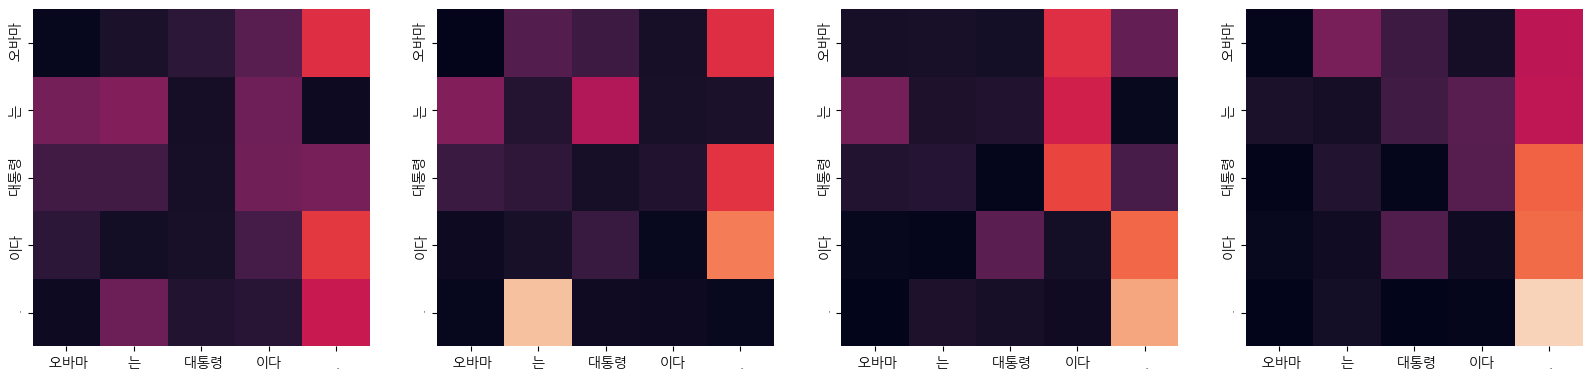

Encoder Layer 2


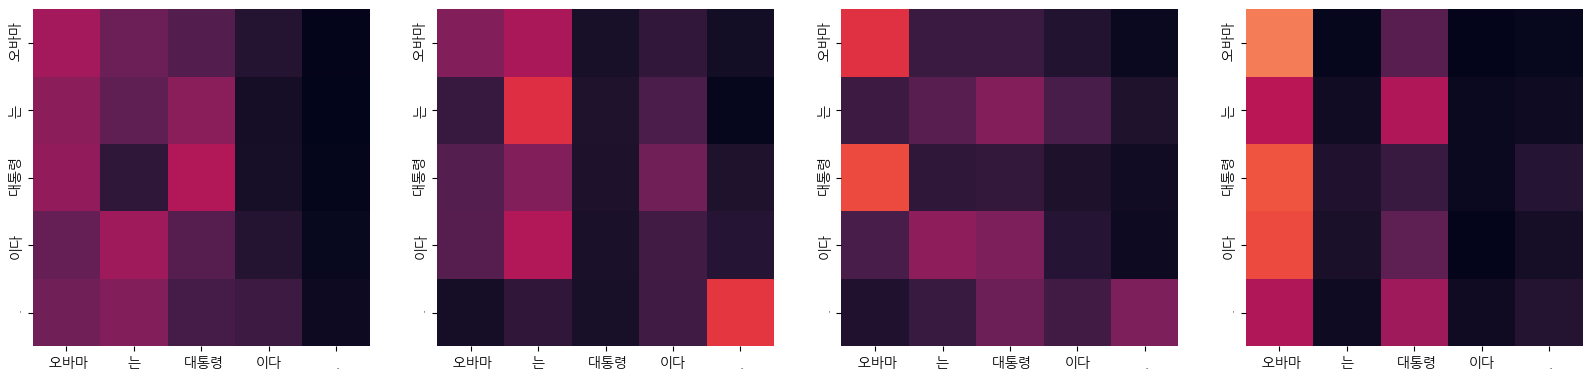

Decoder Self Layer 1


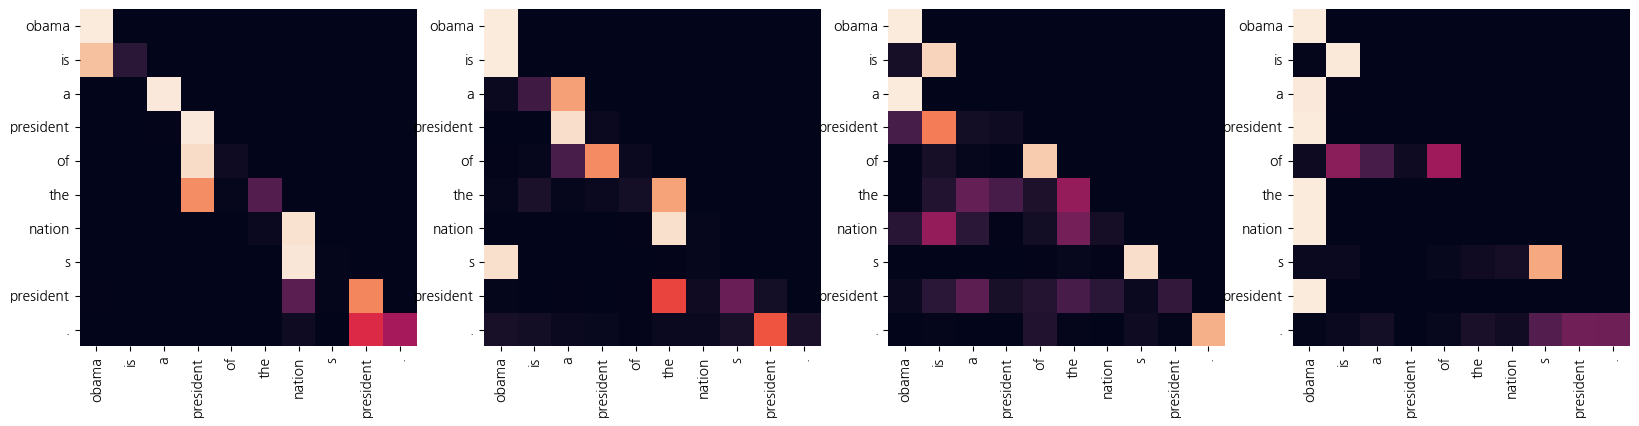

Decoder Src Layer 1


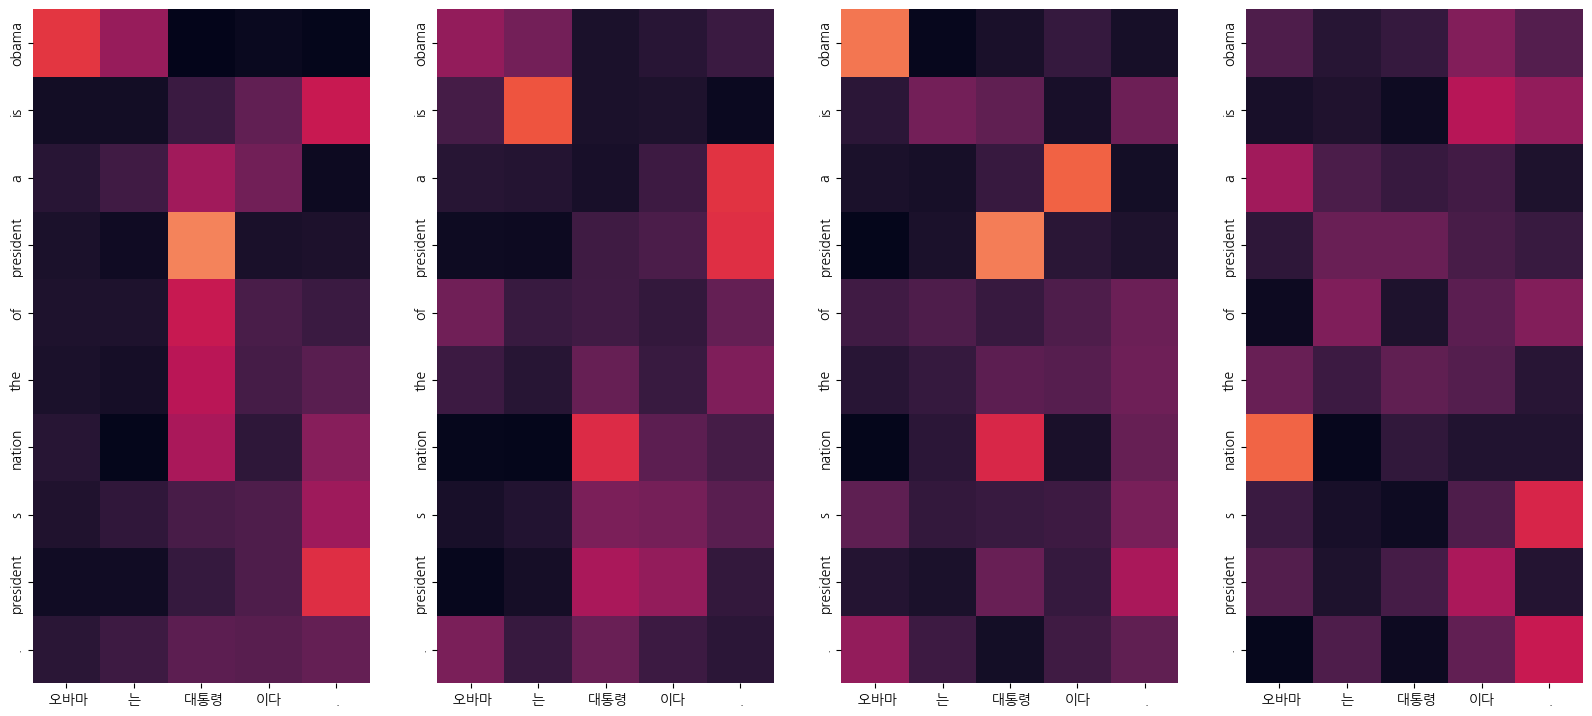

Decoder Self Layer 2


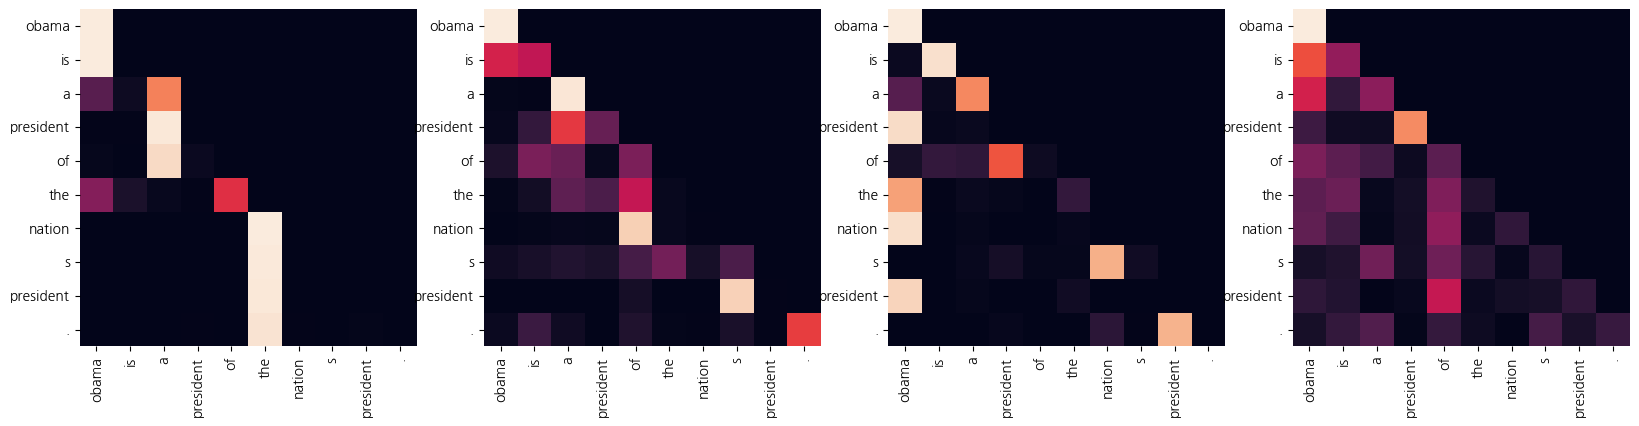

Decoder Src Layer 2


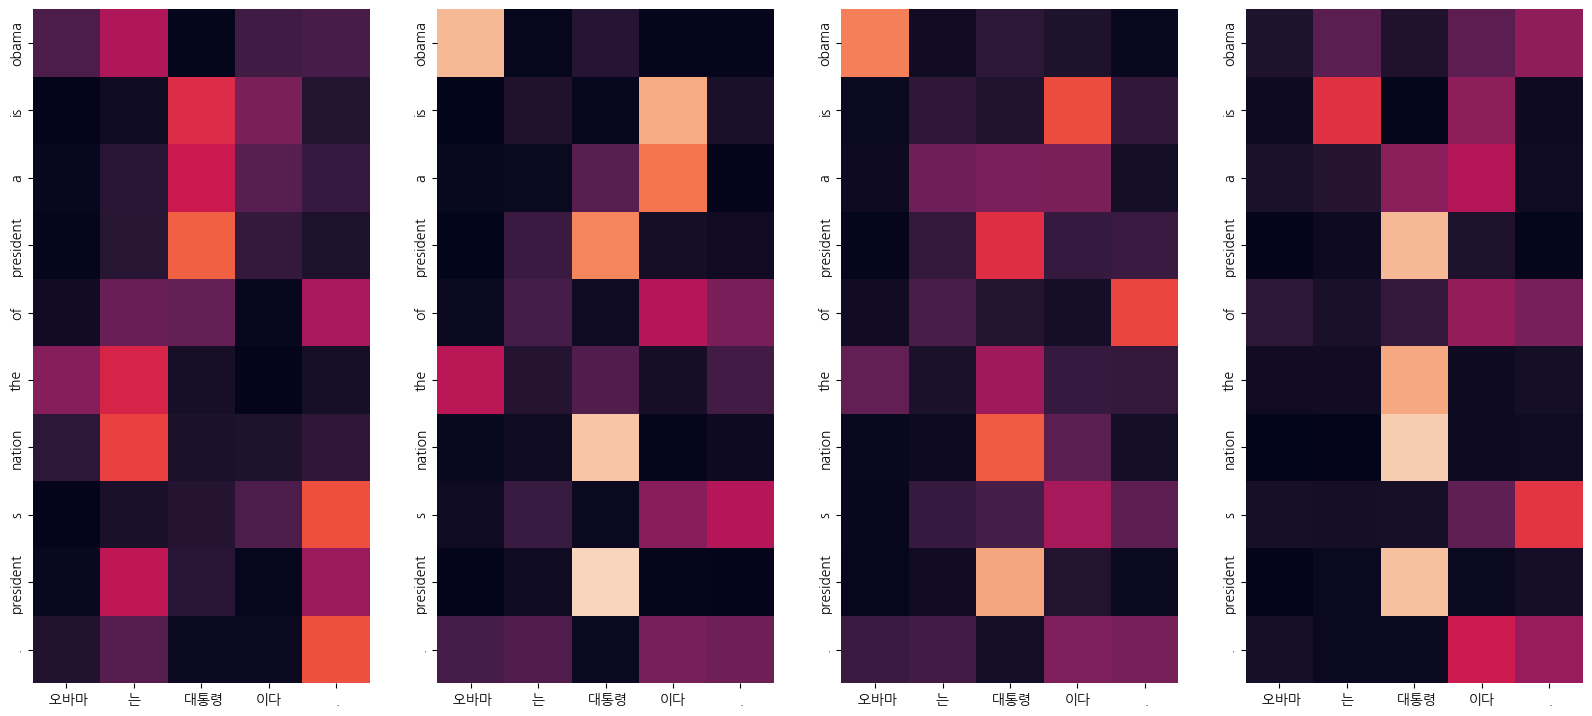

In [30]:
translate("오바마는 대통령이다.", transformer, ko_tokenizer, en_tokenizer, plot_attention=True)

---
### **제출 정리**
---
아래 항목을 정리해서 제출합니다. (루브릭 3개 항목과 매칭)

1. **전처리 결과**: 원본 약 94,000쌍 → 중복 제거 및 토큰 길이(<=50) 필터 후 **72,107문장**
   (train 69,107 / valid 3,000, 증강 미적용). SentencePiece 서브워드 토큰화, `<PAD>=0 <BOS>=1 <EOS>=2 <UNK>=3` 규약.
2. **최종 하이퍼파라미터** (전 epoch 공통, 정성적으로 Epoch 5, val loss 기준 best는 Epoch 8):
   `N_LAYERS=2`, `D_MODEL=512`, `N_HEADS=8`, `D_FF=2048`, `DROPOUT=0.2`,
   `WARMUP_STEPS=4000`, `BATCH_SIZE=64`, `EPOCH=20` (best_val_loss=4.6141, 파라미터 35.2M)
3. **테스트 예문 4개 답변** (정성적으로 가장 좋았던 Epoch 5):
   - 오바마는 대통령이다. -> `obama is the president .`
   - 시민들은 도시 속에 산다. -> `citizens are in the city .`
   - 커피는 필요 없다. -> `coffee said it wasn t necessary .`
   - 일곱 명의 사망자가 발생했다. -> `about people were killed , according to the associated press .`
4. **BLEU Score**: 검증셋 300문장 코퍼스 BLEU **5.32** (best 모델 기준, sacrebleu)


---
### **적용된 업그레이드**
---
1. **디코딩 반복 억제**: no-repeat 3-gram으로 "democratic democratic…", "city of the city" 같은 반복 붕괴 제거
2. **검증셋 분리**: 원본을 train/valid로 분리(valid 최대 3,000, 미증강), val loss 기준 best 가중치 저장 후 학습 종료 시 복원(early stopping에 준하는 효과), BLEU도 valid로 측정
3. **매 epoch 배치 셔플**: 배치 순서를 매 epoch 셔플(과적합 완화), train/val 분리는 randperm 시드 고정
4. **학습 안정화**: Xavier 초기화(초기 loss 폭주 방지) + gradient clipping(1.0) + label smoothing(0.1)
5. **기타**: torch/numpy/random 시드 고정(42), 임베딩 스케일(sqrt(d_model)) 적용, 논문 4.3절 Warmup LR 스케줄


---
### **회고**
---
**배운 점**
1. teacher forcing의 함정: causal 마스크 부호가 뒤집히면 학습 땐 미래 정답을 훔쳐봐서 train loss는 잘 떨어지는데 실제 생성은 붕괴한다 -> "loss가 낮다 != 잘 된다".
2. cross-attention에는 causal 마스크를 걸면 안 됨(디코더는 소스 문장 전체를 봐야 하므로 인코더 패딩 마스크만 사용).
3. Seq2Seq에서 타겟 임베딩과 출력층 가중치를 공유(weight tying)해 파라미터를 줄일 수 있다는 점을 shared 옵션으로 확인.
4. 평가 지표의 정직성. 학습셋으로 잰 BLEU는 과대평가라, 반드시 안 본 검증셋으로 측정해야 한다(held-out BLEU 5.32).

**어려웠던 점**
1. 겉보기엔 정상(loss 하강)인데 답변이 이상해 원인 찾기가 어려웠던 점 -> 마스크 규약(1=차단)을 통일하고 어텐션이 패딩에 쏠리지 않도록 부호를 바로잡아 해결.
2. 실행 차단 버그가 곳곳에 있었음: optimizer/scheduler 정의 순서(NameError), 손실 함수 차원, positional encoding 타입, import 누락, GPU 이동 누락 -> 모델이 학습되기 전에 파이프라인부터 맞춰야 했다.
3. 초기 loss가 수천대로 폭주 -> Xavier 초기화 + gradient clipping으로 안정화. Colab 세션 끊김 대비 best 가중치 저장/복원과 시드 고정으로 재현성 확보.

**아쉬운 점 / 한계**
1. 데이터가 뉴스 도메인에 편중되고 2-layer 소형 모델이라 과적합이 빠르게 옴. train loss는 Epoch 20까지 계속 하락(3.16)했지만 val loss는 Epoch 8(4.61)에서 최저 후 상승.
2. 후반 epoch에서는 원문에 없는 고유명사(illinois, san francisco, san diego)를 지어내는 hallucination이 나타남. 정성 품질이 오히려 나빠져 best 모델 복원 로직이 실질적으로 필요했다.
3. greedy 디코딩 한계. 반복은 억제했지만 답이 짧고 일반적이며, 정답이 하나가 아니라 BLEU가 본질적으로 낮음(5.32).

**다음에 시도할 것**
1. 디코딩 개선: greedy를 beam search(beam 4~5) 또는 top-k/top-p 샘플링으로 바꿔, 짧고 일반적인 답변과 반복 문제를 완화하고 BLEU를 재측정한다.
2. 과적합 대응: 이번에 val loss가 Epoch 8에서 꺾인 만큼 early stopping(patience 2~3)을 명시적으로 적용하고, dropout 상향과 데이터 증강(역번역 등)으로 일반화 성능을 높인다.
3. 데이터·모델 규모 확대: 뉴스 편중을 줄이도록 도메인을 다양화하고, 사전학습 모델(mBART, KoBART/T5) fine-tuning으로 소규모 데이터 한계와 hallucination을 극복한다.
4. 하이퍼파라미터 체계적 탐색: layer 수, d_model, warmup_steps를 val 곡선을 보며 조정하고, best epoch(5~8) 부근에서 학습을 관리한다.
5. 평가 보강: BLEU 단독 대신 BERTScore 등 임베딩 기반 지표와 정성평가를 병행하고, epoch별 BLEU 곡선을 함께 기록한다.